In [18]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


df = pd.read_csv('Dataset.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [20]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [21]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

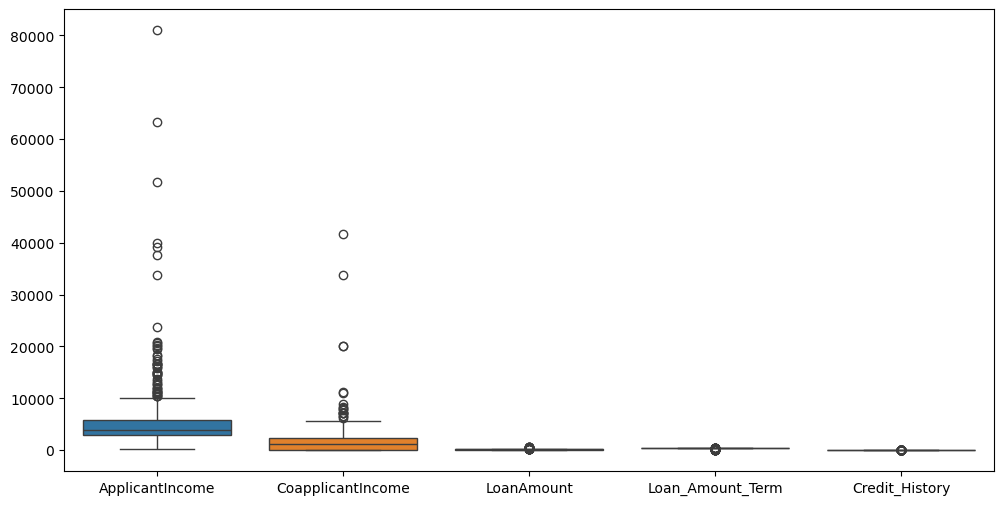

In [22]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.show()

In [23]:
# Fill the null values of numerical datatypes
df['LoanAmount']=df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term']=df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())
df['Credit_History']=df['Credit_History'].fillna(df['Credit_History'].mean())


In [24]:
# Fill the null values of object datatypes
df['Gender']=df['Gender'].fillna(df['Gender'].mode()[0])
df['Married']=df['Married'].fillna(df['Married'].mode()[0])
df['Dependents']=df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed']=df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])



In [25]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

Number of people who took loan by gender
Gender
Male      502
Female    112
Name: count, dtype: int64


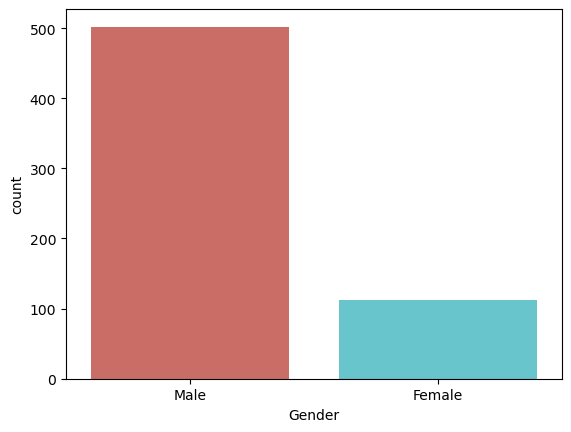

In [26]:
print('Number of people who took loan by gender')
print(df['Gender'].value_counts())
sns.countplot(x='Gender',data=df,palette='hls')
plt.show()

Number of people who took loan by Married
Married
Yes    401
No     213
Name: count, dtype: int64


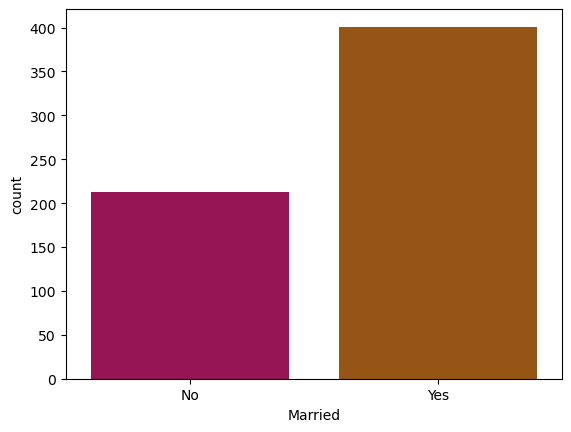

In [27]:
print('Number of people who took loan by Married')
print(df['Married'].value_counts())
sns.countplot(x='Married',data=df,palette='brg')
plt.show()

In [30]:
corr = df.corr(numeric_only=True)

corr

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000000,-0.116605,0.565181,-0.046531,-0.014477
CoapplicantIncome,-0.116605,1.000000,0.189218,-0.059383,-0.001665
LoanAmount,0.565181,0.189218,1.000000,0.036960,-0.007031
Loan_Amount_Term,-0.046531,-0.059383,0.036960,1.000000,-0.003546
Credit_History,-0.014477,-0.001665,-0.007031,-0.003546,1.000000


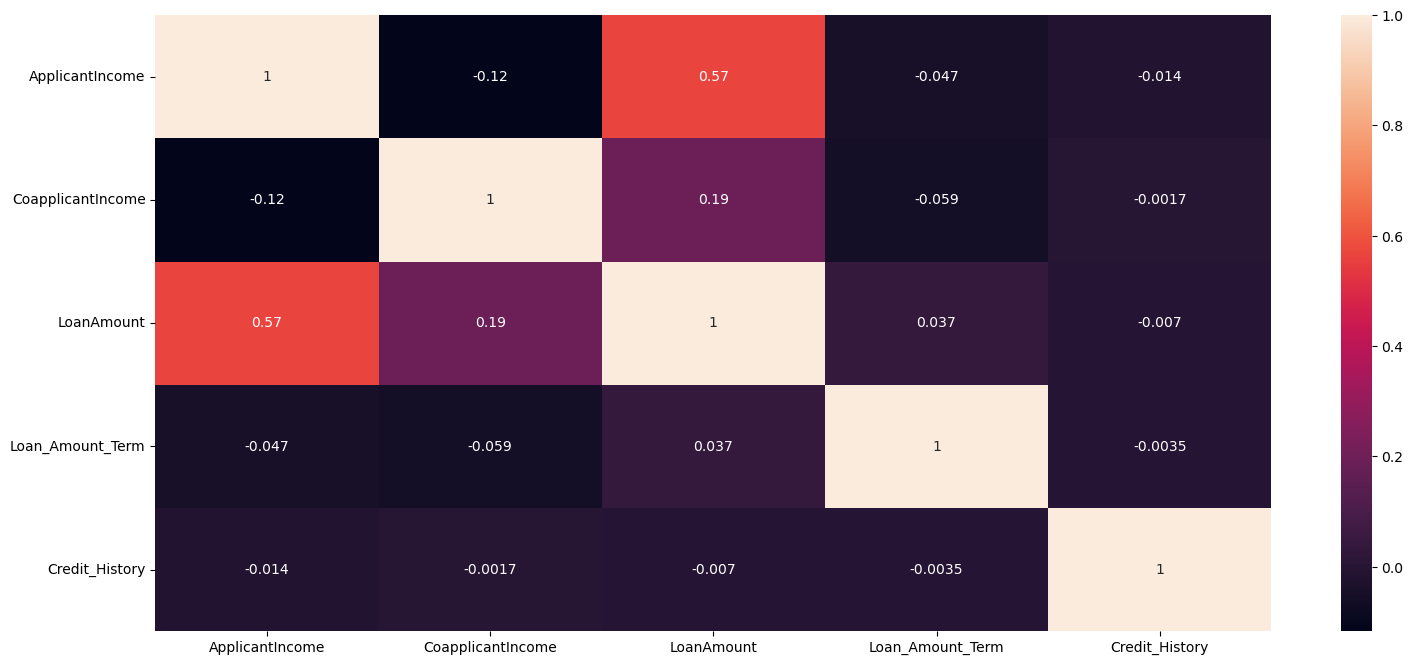

In [33]:


plt.figure(figsize=(18,8))
sns.heatmap(corr,annot=True)
plt.show()

In [34]:
## Total Applicant Income
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,5849.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0


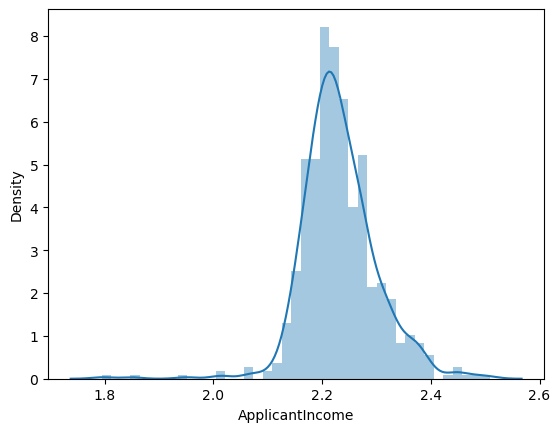

In [41]:
## Apply log transformation
df['ApplicantIncome_log'] = np.log(df['ApplicantIncome']+1)
df['CoapplicantIncome_log'] = np.log(df['CoapplicantIncome']+1)
df['LoanAmount_log'] = np.log(df['LoanAmount']+1)
df['Loan_Amount_Term_log'] = np.log(df['Loan_Amount_Term']+1)
df['Total_Income_log'] = np.log(df['Total_Income']+1)
sns.distplot(df['ApplicantIncome'])
plt.show()

In [42]:
## Drop unnecessary columns
df = df.drop(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Total_Income', 'Loan_ID'], axis=1)
df.head()

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,Loan_Status,ApplicantIncome_log,CoapplicantIncome_log,LoanAmount_log,Loan_Amount_Term_log,Total_Income_log
0,Male,No,0,Graduate,No,1.0,Urban,Y,1.184626,0.000000,1.768118,1.929908,2.269462
1,Male,Yes,1,Graduate,No,1.0,Rural,N,1.176786,2.118566,1.768118,1.929908,2.273643
2,Male,Yes,0,Graduate,Yes,1.0,Urban,Y,1.162516,0.000000,1.649561,1.929908,2.197969
3,Male,Yes,0,Not Graduate,No,1.0,Urban,Y,1.157264,2.170880,1.757132,1.929908,2.251873
4,Male,No,0,Graduate,No,1.0,Urban,Y,1.185430,0.000000,1.784370,1.929908,2.272093


In [44]:
## Encoding Technique
from sklearn.preprocessing import LabelEncoder
cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
le = LabelEncoder()
for i in cols:
    df[i] = le.fit_transform(df[i])
df.head()

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,Loan_Status,ApplicantIncome_log,CoapplicantIncome_log,LoanAmount_log,Loan_Amount_Term_log,Total_Income_log
0,1,0,0,0,0,1.0,2,1,1.184626,0.000000,1.768118,1.929908,2.269462
1,1,1,1,0,0,1.0,0,0,1.176786,2.118566,1.768118,1.929908,2.273643
2,1,1,0,0,1,1.0,2,1,1.162516,0.000000,1.649561,1.929908,2.197969
3,1,1,0,1,0,1.0,2,1,1.157264,2.170880,1.757132,1.929908,2.251873
4,1,0,0,0,0,1.0,2,1,1.185430,0.000000,1.784370,1.929908,2.272093


In [45]:
df.dtypes

Gender                     int64
Married                    int64
Dependents                 int64
Education                  int64
Self_Employed              int64
Credit_History           float64
Property_Area              int64
Loan_Status                int64
ApplicantIncome_log      float64
CoapplicantIncome_log    float64
LoanAmount_log           float64
Loan_Amount_Term_log     float64
Total_Income_log         float64
dtype: object

In [51]:
## Create X and y
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

## Train Test Split
from sklearn.model_selection import train_test_split, cross_val_score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

## Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


lr = LogisticRegression()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()
knn = KNeighborsClassifier()
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
knn.fit(X_train, y_train)

print('Logistic Regression: ', accuracy_score(y_test, lr.predict(X_test)))
print('Decision Tree: ', accuracy_score(y_test, dt.predict(X_test)))
print('Random Forest: ', accuracy_score(y_test, rf.predict(X_test)))
print('KNN: ', accuracy_score(y_test, knn.predict(X_test)))

Logistic Regression:  0.8311688311688312
Decision Tree:  0.7597402597402597
Random Forest:  0.8051948051948052
KNN:  0.8181818181818182


In [59]:
scores = cross_val_score(lr, X, y, cv=10)
print(scores)
print(scores.mean())
print(scores.std())


[0.80645161 0.82258065 0.77419355 0.75806452 0.78688525 0.78688525
 0.86885246 0.85245902 0.80327869 0.83606557]
0.8095716552088842
0.03347832020344735


In [60]:
scores2 = cross_val_score(dt, X, y, cv=10)
print(scores2)
print(scores2.mean())


[0.74193548 0.74193548 0.67741935 0.67741935 0.7704918  0.70491803
 0.78688525 0.72131148 0.72131148 0.83606557]
0.7379693283976732
